# Proyecto Predictivo - Analisis y Modelado (Dataset Electrico 2107)

Este notebook contiene el proceso completo de mineria de datos.
No se incluyen tildes por compatibilidad.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuraciones visuales basicas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', 150)

# Carga de datos optimizada
DATA_PATH = Path(r'c:\Universidad\mineria\predictivo\data\2107_electrical_data.csv')

# Determinamos tipos de datos usando una muestra
sample_df = pd.read_csv(DATA_PATH, nrows=10)
dtypes = {col: 'float32' for col in sample_df.columns if col != 'measured_on'}

print("Cargando el dataset...")
df = pd.read_csv(DATA_PATH, dtype=dtypes, parse_dates=['measured_on'])
# Usaremos measured_on como indice temporal
df.set_index('measured_on', inplace=True)
print("Carga completa.")

Cargando el dataset...


Carga completa.


## 1. Comprension Estructural del Dataset

Revisamos inventario de columnas, el rango de fechas y una vista rapida de los datos.

In [3]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Rango temporal: desde {df.index.min()} hasta {df.index.max()}")
print(f"Total de dias: {(df.index.max() - df.index.min()).days}")

print("\nTipos de variables:")
print(df.dtypes.value_counts())

display(df.head())

Dimensiones del dataset: (632952, 119)
Rango temporal: desde 2017-11-01 00:00:00 hasta 2023-11-07 23:55:00
Total de dias: 2197

Tipos de variables:
float32    119
Name: count, dtype: int64


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,inv_03_dc_current_inv_149589,inv_03_dc_voltage_inv_149590,inv_03_ac_current_inv_149591,inv_03_ac_voltage_inv_149592,inv_03_ac_power_inv_149593,inv_04_dc_current_inv_149594,inv_04_dc_voltage_inv_149595,inv_04_ac_current_inv_149596,inv_04_ac_voltage_inv_149597,inv_04_ac_power_inv_149598,inv_05_dc_current_inv_149599,inv_05_ac_current_inv_149601,inv_05_ac_voltage_inv_149602,inv_05_ac_power_inv_149603,inv_06_dc_current_inv_149604,inv_06_dc_voltage_inv_149605,inv_06_ac_current_inv_149606,inv_06_ac_voltage_inv_149607,inv_06_ac_power_inv_149608,inv_07_dc_current_inv_149609,inv_07_dc_voltage_inv_149610,inv_07_ac_current_inv_149611,inv_07_ac_voltage_inv_149612,inv_07_ac_power_inv_149613,inv_08_dc_current_inv_149614,inv_08_dc_voltage_inv_149615,inv_08_ac_current_inv_149616,inv_08_ac_voltage_inv_149617,inv_08_ac_power_inv_149618,inv_09_dc_current_inv_149619,inv_09_dc_voltage_inv_149620,inv_09_ac_current_inv_149621,inv_09_ac_voltage_inv_149622,inv_09_ac_power_inv_149623,inv_10_dc_current_inv_149624,inv_10_dc_voltage_inv_149625,inv_10_ac_current_inv_149626,inv_10_ac_voltage_inv_149627,inv_10_ac_power_inv_149628,inv_11_dc_current_inv_149629,inv_11_dc_voltage_inv_149630,inv_11_ac_current_inv_149631,inv_11_ac_voltage_inv_149632,inv_11_ac_power_inv_149633,inv_12_dc_current_inv_149634,inv_12_dc_voltage_inv_149635,inv_12_ac_current_inv_149636,inv_12_ac_voltage_inv_149637,inv_12_ac_power_inv_149638,inv_13_dc_current_inv_149639,inv_13_dc_voltage_inv_149640,inv_13_ac_current_inv_149641,inv_13_ac_voltage_inv_149642,inv_13_ac_power_inv_149643,inv_14_dc_current_inv_149644,inv_14_dc_voltage_inv_149645,inv_14_ac_current_inv_149646,inv_14_ac_voltage_inv_149647,inv_14_ac_power_inv_149648,inv_15_dc_current_inv_149649,inv_15_dc_voltage_inv_149650,inv_15_ac_current_inv_149651,inv_15_ac_voltage_inv_149652,inv_15_ac_power_iinv_149653,inv_16_dc_current_inv_149654,inv_16_dc_voltage_inv_149655,inv_16_ac_current_inv_149656,inv_16_ac_voltage_inv_149657,inv_16_ac_power_inv_149658,inv_17_dc_current_inv_149659,inv_17_dc_voltage_inv_149660,inv_17_ac_current_inv_149661,inv_17_ac_voltage_inv_149662,inv_17_ac_power_inv_149663,inv_18_dc_current_inv_149664,inv_18_dc_voltage_inv_149665,inv_18_ac_current_inv_149666,inv_18_ac_voltage_inv_149667,inv_18_ac_power_inv_149668,inv_19_dc_current_inv_149669,inv_19_dc_voltage_inv_149670,inv_19_ac_current_inv_149671,inv_19_ac_voltage_inv_149672,inv_19_ac_power_inv_149673,inv_20_dc_current_inv_149674,inv_20_dc_voltage_inv_149675,inv_20_ac_current_inv_149676,inv_20_ac_voltage_inv_149677,inv_20_ac_power_inv_149678,inv_21_dc_current_inv_149679,inv_21_dc_voltage_inv_149680,inv_21_ac_current_inv_149681,inv_21_ac_voltage_inv_149682,inv_21_ac_power_inv_149683,inv_22_dc_current_inv_149684,inv_22_dc_voltage_inv_149685,inv_22_ac_current_inv_149686,inv_22_ac_voltage_inv_149687,inv_22_ac_power_inv_149688,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
measured_on,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

## 2. Analisis de Calidad del Dato

Siguiendo las mejores practicas, revisamos:
1. Valores nulos
2. Sensores muertos (varianza cero)
3. Sensores con baja variabilidad (std <= 0.1)

In [4]:
# 2.1 Resumen de nulos
nulos = (
    df.isna()
    .sum()
    .rename("conteo_nulos")
    .to_frame()
    .assign(pct_nulos=lambda t: (t["conteo_nulos"] / len(df)) * 100)
    .sort_values("conteo_nulos", ascending=False)
)

columnas_con_nulos = nulos[nulos['conteo_nulos'] > 0]
print(f"Columnas con nulos: {len(columnas_con_nulos)} de {df.shape[1]}")
display(columnas_con_nulos.head(10))

Columnas con nulos: 114 de 119


,conteo_nulos,pct_nulos
inv_04_dc_voltage_inv_149595,1728,0.273006
inv_04_ac_current_inv_149596,1728,0.273006
inv_04_ac_voltage_inv_149597,1728,0.273006
inv_04_ac_power_inv_149598,1728,0.273006
inv_05_dc_current_inv_149599,1728,0.273006
inv_05_ac_current_inv_149601,1728,0.273006
inv_05_ac_voltage_inv_149602,1728,0.273006
inv_04_dc_current_inv_149594,1728,0.273006
inv_08_ac_voltage_inv_149617,1728,0.273006
inv_08_ac_current_inv_149616,1728,0.273006


In [5]:
# 2.2 Varianza cero (sensores muertos)
df_std = df.std(numeric_only=True)
cols_desv_cero = df_std[df_std == 0].index.tolist()

print(f"Sensores con desviacion estandar 0: {len(cols_desv_cero)}")
if len(cols_desv_cero) > 0:
    print(cols_desv_cero)
    # Eliminamos las columnas que no aportan informacion
    df = df.drop(columns=cols_desv_cero)
    print("Columnas eliminadas.")

# 2.3 Baja varianza
tolerancia = 0.1
cols_baja_desv = df.std(numeric_only=True)[df.std(numeric_only=True) <= tolerancia].index.tolist()
print(f"\nSensores con baja variabilidad (<= {tolerancia}): {len(cols_baja_desv)}")
# Por ahora solo listamos las de baja varianza sin eliminarlas hasta tener mas contexto
if len(cols_baja_desv) > 0:
    print(cols_baja_desv[:10]) # Mostramos primeras 10

Sensores con desviacion estandar 0: 0



Sensores con baja variabilidad (<= 0.1): 0


## 3. Limpieza de Datos (Filtro Fisico)

Antes de realizar la estadistica descriptiva y el EDA visual, debemos filtrar valores fisicamente imposibles originados por fallas en los sensores del SCADA (outliers).
- Voltaje DC: Un inversor de esta categoria no excede los 1500 V.
- Voltaje AC: Conexion a red estandar, no excede 500 V.
- Corriente: No excede 200 A.
- Potencia AC: Maximo nominal ~30 kW (segun descubrimiento previo).

In [6]:
# Filtro fisico de outliers
df_clean = df.copy()

# Listas de columnas por tipo
cols_dc_v = [c for c in df_clean.columns if 'dc_voltage' in c]
cols_ac_v = [c for c in df_clean.columns if 'ac_voltage' in c]
cols_dc_i = [c for c in df_clean.columns if 'dc_current' in c]
cols_ac_i = [c for c in df_clean.columns if 'ac_current' in c]
cols_ac_p = [c for c in df_clean.columns if 'ac_power' in c and 'total' not in c]

# Aplicar mascaras (reemplazar con NaN si superan limites fisicos)
for col in cols_dc_v: df_clean.loc[df_clean[col] > 1500, col] = np.nan
for col in cols_ac_v: df_clean.loc[df_clean[col] > 500, col] = np.nan
for col in cols_dc_i: df_clean.loc[df_clean[col] > 200, col] = np.nan
for col in cols_ac_i: df_clean.loc[df_clean[col] > 200, col] = np.nan
for col in cols_ac_p: df_clean.loc[df_clean[col] > 50, col] = np.nan

# Recalcular total_ac_power con los datos limpios
df_clean['total_ac_power'] = df_clean[cols_ac_p].sum(axis=1)

print("Datos limpios creados exitosamente.")

Datos limpios creados exitosamente.


Apagon SCADA detectado desde: 2023-11-06 17:30:00 hasta 2023-11-07 23:55:00


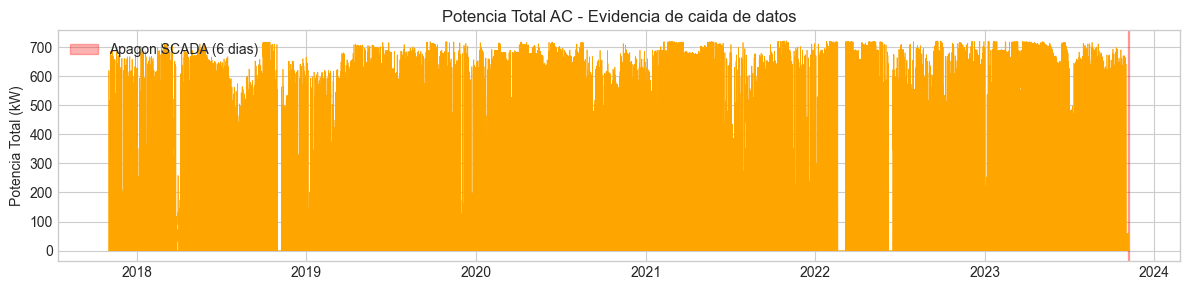

In [7]:
# Localizacion del bloque de 6 dias sin datos
# Usamos una columna especifica para detectar los nulos masivos
col_ref = [c for c in df_clean.columns if 'inv_01_ac_power' in c][0]
filas_nulas = df_clean[col_ref].isna()

if filas_nulas.any():
    fecha_inicio = df_clean[filas_nulas].index.min()
    fecha_fin = df_clean[filas_nulas].index.max()
    print(f"Apagon SCADA detectado desde: {fecha_inicio} hasta {fecha_fin}")
    
    # Graficamos la caida para evidenciarla en el EDA
    plt.figure(figsize=(12, 3))
    plt.plot(df_clean.index, df_clean['total_ac_power'], color='orange', linewidth=0.5)
    plt.axvspan(fecha_inicio, fecha_fin, color='red', alpha=0.3, label='Apagon SCADA (6 dias)')
    plt.title('Potencia Total AC - Evidencia de caida de datos')
    plt.ylabel('Potencia Total (kW)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Estadisticas Descriptivas Post-Limpieza

Con la basura electronica eliminada, podemos confiar en las medidas de tendencia central y dispersion.

In [8]:
# 4.1 Estadisticas y Coeficiente de Variacion
desc = df_clean.describe().T
desc['cv'] = (desc['std'] / desc['mean']).replace([np.inf, -np.inf], np.nan).round(2)

print("=== Resumen Estadistico de Potencia AC por Inversor ===")
display(desc.loc[cols_ac_p, ['count', 'mean', 'std', 'min', '50%', 'max', 'cv']])

=== Resumen Estadistico de Potencia AC por Inversor ===


,count,mean,std,min,50%,max,cv
inv_01_ac_power_inv_149583,632586.0,6.363338,9.933949,0.0,0.0,30.096001,1.56
inv_02_ac_power_inv_149588,632586.0,5.982282,9.607771,0.0,0.0,30.087999,1.61
inv_03_ac_power_inv_149593,632952.0,6.500056,9.909333,0.0,0.0,30.091999,1.52
inv_04_ac_power_inv_149598,631223.0,6.130188,9.856085,0.0,0.0,30.091999,1.61
inv_05_ac_power_inv_149603,631224.0,6.415813,9.924226,0.0,0.0,30.084999,1.55
inv_06_ac_power_inv_149608,631224.0,5.834427,9.589360,0.0,0.0,30.086000,1.64
inv_07_ac_power_inv_149613,631223.0,5.879632,9.771081,0.0,0.0,30.091999,1.66
inv_08_ac_power_inv_149618,631224.0,6.564618,10.089930,0.0,0.0,30.089001,1.54
inv_09_ac_power_inv_149623,631224.0,6.821695,10.228336,0.0,0.0,30.089001,1.50
inv_10_ac_power_inv_149628,631224.0,6.649021,10.122900,0.0,0.0,30.087999,1.52


## 5. EDA Visual con Contexto Solar

Analizamos graficamente el comportamiento de la planta, aplicando los conceptos del docente pero ajustados a datos solares.

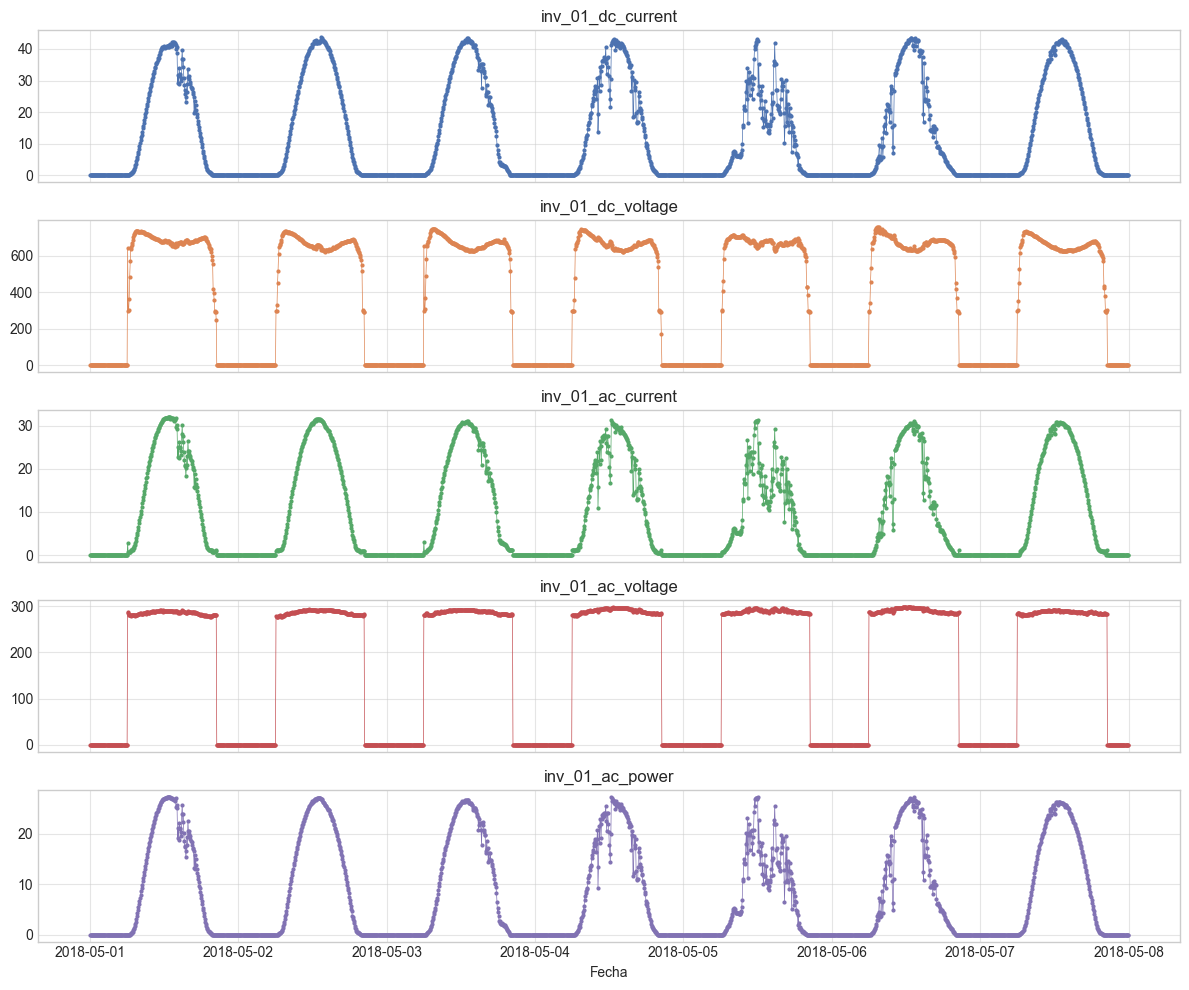

In [9]:
# 5.1 Series de Tiempo Representativas (Inversor 01)
# Extraemos una semana de ejemplo de los datos limpios (Mayo 2018)
df_semana = df_clean.loc['2018-05-01':'2018-05-07']
cols_inv01 = [c for c in df_clean.columns if 'inv_01' in c]

fig, axes = plt.subplots(len(cols_inv01), 1, figsize=(12, 10), sharex=True)
for i, col in enumerate(cols_inv01):
    axes[i].plot(df_semana.index, df_semana[col], marker='o', markersize=2, linestyle='-', linewidth=0.5, color='C'+str(i))
    axes[i].set_title(col.split('_inv')[0])
    axes[i].grid(True, alpha=0.5)

plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

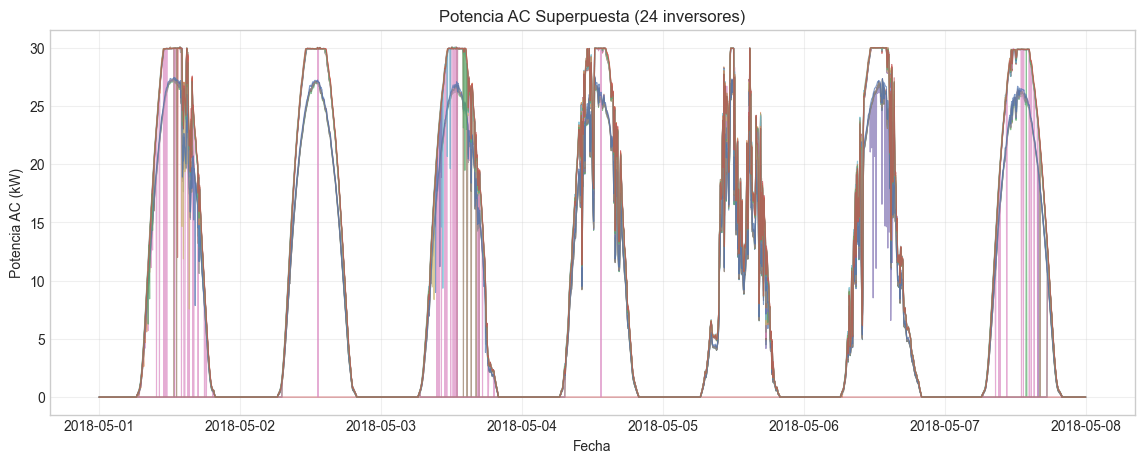

In [10]:
# 5.2 Superposicion de Potencia AC (Homogeneidad de la Planta)
plt.figure(figsize=(14, 5))
for col in cols_ac_p:
    plt.plot(df_semana.index, df_semana[col], linewidth=0.8, alpha=0.7)

plt.title('Potencia AC Superpuesta (24 inversores)')
plt.ylabel('Potencia AC (kW)')
plt.xlabel('Fecha')
plt.grid(True, alpha=0.3)
plt.show()

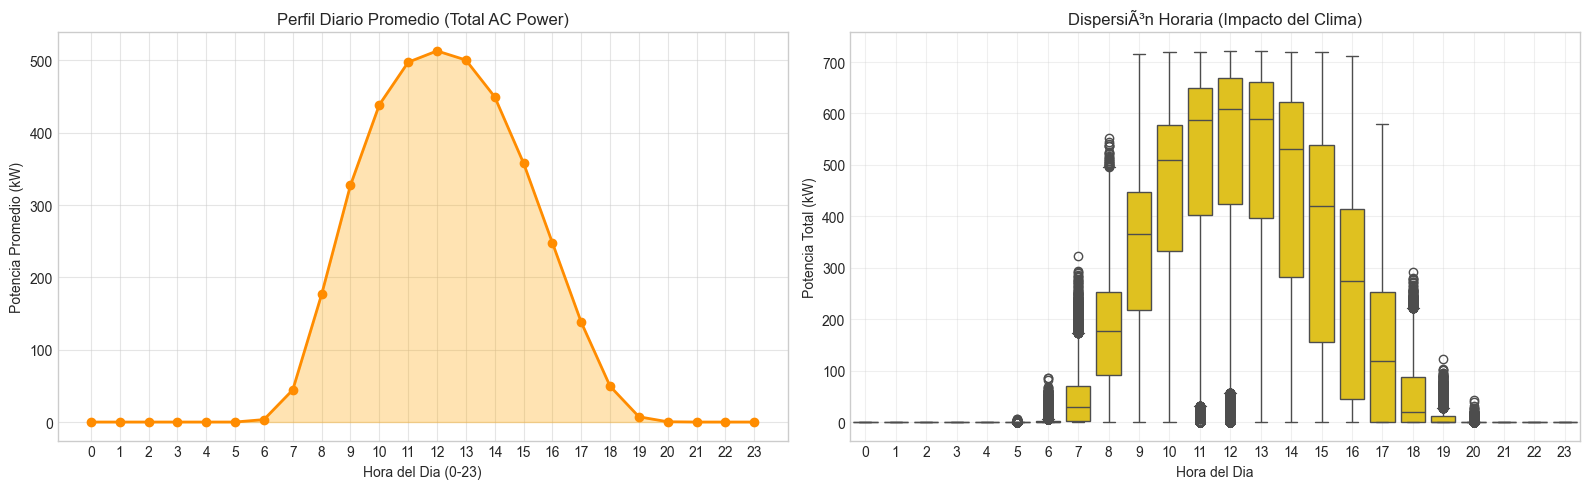

In [11]:
# 5.3 Perfil Diario Promedio y Boxplots de Variabilidad
# Agrupamos por hora del dia
df_hora = df_clean.groupby(df_clean.index.hour)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Promedio horario de potencia total
promedio_hora = df_hora['total_ac_power'].mean()
axes[0].plot(promedio_hora.index, promedio_hora.values, marker='o', color='darkorange', linewidth=2)
axes[0].fill_between(promedio_hora.index, promedio_hora.values, alpha=0.3, color='orange')
axes[0].set_title('Perfil Diario Promedio (Total AC Power)')
axes[0].set_xlabel('Hora del Dia (0-23)')
axes[0].set_ylabel('Potencia Promedio (kW)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.5)

# Boxplot horario para ver variabilidad (dias nublados vs soleados)
df_clean['hora'] = df_clean.index.hour
sns.boxplot(x='hora', y='total_ac_power', data=df_clean, ax=axes[1], color='gold')
axes[1].set_title('DispersiÃ³n Horaria (Impacto del Clima)')
axes[1].set_xlabel('Hora del Dia')
axes[1].set_ylabel('Potencia Total (kW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Borramos la columna auxiliar 'hora' para no afectar futuros calculos
df_clean.drop(columns=['hora'], inplace=True)

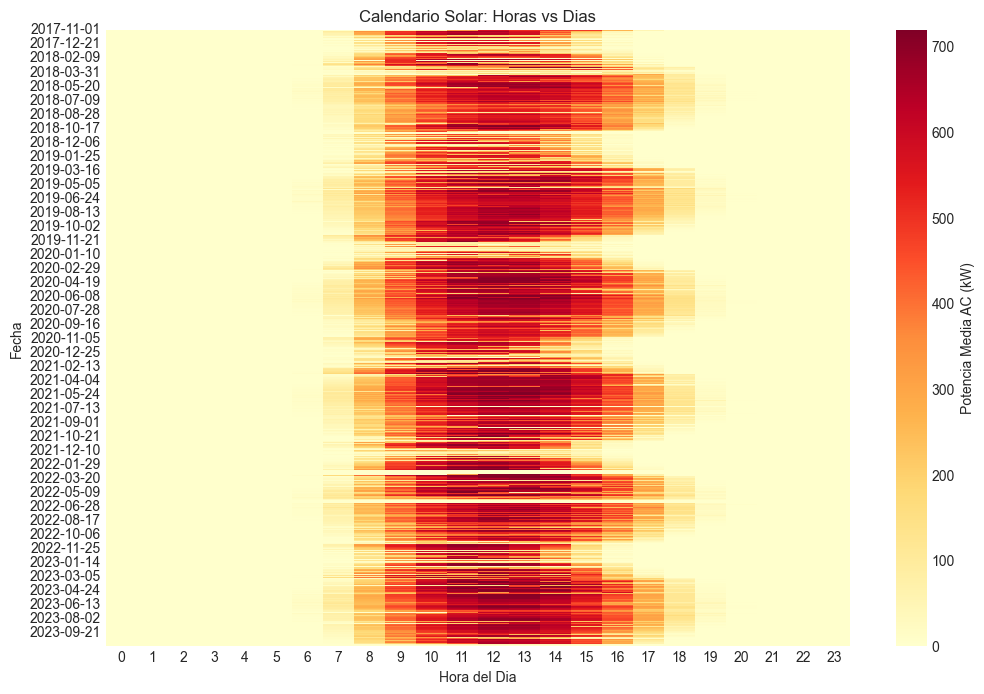

In [12]:
# 5.4 Heatmap de Generacion (Calendario Solar)
# Matriz bidimensional: dia del ano vs hora del dia
df_heatmap = df_clean.copy()
df_heatmap['dia'] = df_heatmap.index.date
df_heatmap['hora'] = df_heatmap.index.hour

# Pivotamos para tener dias en Y y horas en X
matriz_solar = df_heatmap.pivot_table(index='dia', columns='hora', values='total_ac_power', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_solar, cmap='YlOrRd', cbar_kws={'label': 'Potencia Media AC (kW)'})
plt.title('Calendario Solar: Horas vs Dias')
plt.xlabel('Hora del Dia')
plt.ylabel('Fecha')
plt.show()

## 6. Analisis de Distribuciones y Ceros Nocturnos

Evaluamos como se distribuyen los datos fisicos y cuantificamos el sesgo de la "noche" (produccion 0) en la distribucion total.

Total de registros validos de potencia AC: 15,153,826
Registros exactos en 0 kW (Noche/Apagado): 8,326,606 (54.9%)


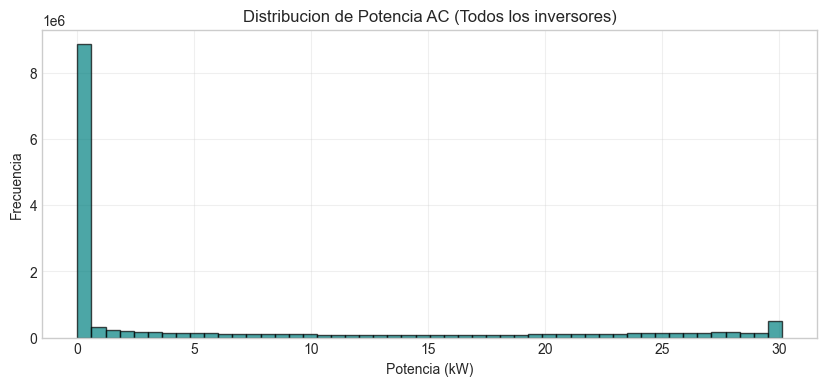

In [13]:
# 6.1 Distribucion Global de ac_power y Cuantificacion de Noches
ac_power_todos = df_clean[cols_ac_p].values.flatten()
ac_power_todos = ac_power_todos[~np.isnan(ac_power_todos)]

ceros = np.sum(ac_power_todos == 0)
total = len(ac_power_todos)
pct_ceros = (ceros / total) * 100

print(f"Total de registros validos de potencia AC: {total:,}")
print(f"Registros exactos en 0 kW (Noche/Apagado): {ceros:,} ({pct_ceros:.1f}%)")

plt.figure(figsize=(10, 4))
plt.hist(ac_power_todos, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribucion de Potencia AC (Todos los inversores)')
plt.xlabel('Potencia (kW)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

# Nota: El pico gigantesco en 0 confirma la extrema bimodalidad del dataset.

## 7. Analisis de Correlacion y Colinealidad (V.I.F)

Como senalo el docente, para la regresion lineal multiple es critico entender la colinealidad.
- Variables fisicas de un mismo inversor (ej. dc_voltage y dc_current) seran nuestras variables predictoras (X).
- ac_power sera nuestra variable objetivo (y).

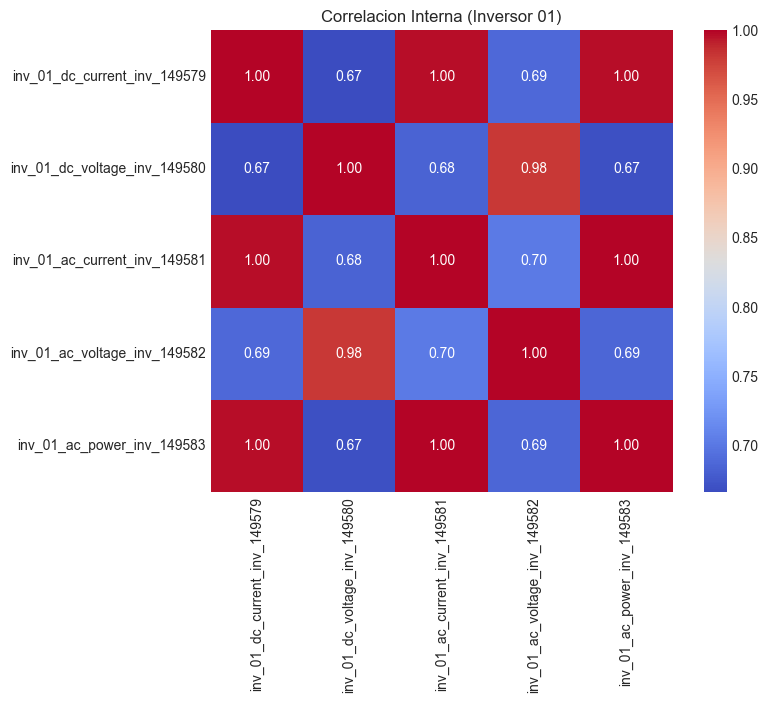

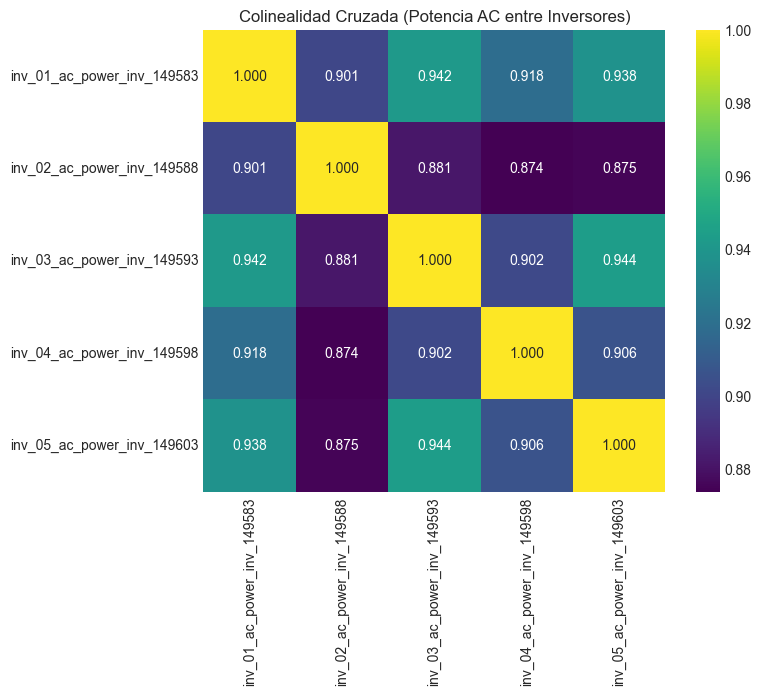

Nota sobre V.I.F:
La correlacion perfecta (~1.0) entre inversores indica alta colinealidad espacial.
Para regresion multiple, usar todos los inversores como predictores causara inestabilidad matematica (inflacion de varianza).


In [14]:
# 7.1 Correlacion Interna (Predictoras vs Objetivo)
# Tomamos el Inversor 01 como muestra representativa
cols_inv01 = [c for c in df_clean.columns if 'inv_01' in c]
df_corr_interna = df_clean[cols_inv01].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_interna, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlacion Interna (Inversor 01)')
plt.show()

# 7.2 Colinealidad entre Inversores (AC Power)
cols_ac_muestra = cols_ac_p[:5] # Primeros 5 inversores para no saturar
df_corr_cruzada = df_clean[cols_ac_muestra].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_cruzada, annot=True, fmt=".3f", cmap='viridis', square=True)
plt.title('Colinealidad Cruzada (Potencia AC entre Inversores)')
plt.show()

print("Nota sobre V.I.F:")
print("La correlacion perfecta (~1.0) entre inversores indica alta colinealidad espacial.")
print("Para regresion multiple, usar todos los inversores como predictores causara inestabilidad matematica (inflacion de varianza).")

## 8. Analisis Temporal Avanzado

Descomponemos la serie temporal para identificar tendencias a largo plazo (degradacion de paneles), estacionalidad y determinamos la estacionariedad con el test de Dickey-Fuller.

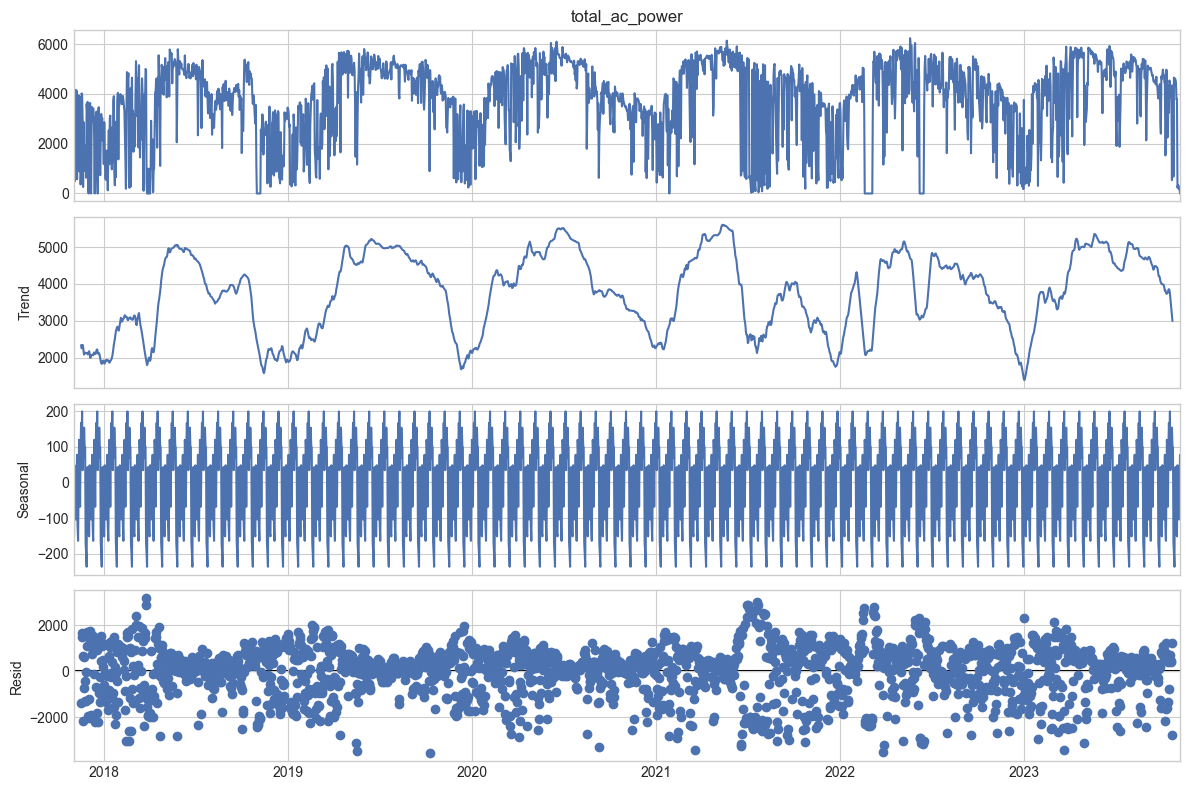

In [15]:
# 8.1 Descomposicion (Tendencia, Estacionalidad, Ruido)
from statsmodels.tsa.seasonal import seasonal_decompose

# Resampleamos a datos diarios (suma de potencia util = Energia aprox)
# Quitamos los nulos para statsmodels y forzamos frecuencia diaria
energia_diaria = df_clean['total_ac_power'].dropna().resample('D').sum() * (5/60)

# Aseguramos que la serie no tenga NaNs intermedios imputandolos
energia_diaria = energia_diaria.fillna(energia_diaria.median())

resultado = seasonal_decompose(energia_diaria, model='additive', period=30) # 30 dias = patron mensual

plt.rcParams.update({'figure.figsize': (12, 8)})
resultado.plot()
plt.tight_layout()
plt.show()

In [16]:
# 8.2 Test de Estacionariedad (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(energia_diaria)
print('Estadistico ADF:', result_adf[0])
print('p-value:', result_adf[1])

if result_adf[1] < 0.05:
    print("Conclusion: La serie es ESTACIONARIA (podemos modelar sin diferenciar).")
else:
    print("Conclusion: La serie NO ES ESTACIONARIA (requerira diferenciacion ej. ARIMA d=1).")

Estadistico ADF: -5.077181105286626
p-value: 1.5578275946818143e-05
Conclusion: La serie es ESTACIONARIA (podemos modelar sin diferenciar).


## 9. Preparacion de Datos (Data Preparation)

El objetivo del modelado predictivo sera pronosticar la **Energia Total Diaria** de la planta. Esto es mas util para un operador de red y nos permite reducir la colinealidad extrema colapsando las 119 variables en promedios diarios por planta.

In [17]:
# 9.1 Manejo de Nulos (Apagon SCADA y Filtros Fisicos)
# Eliminamos las filas del apagon SCADA (donde todas las seÃ±ales importantes son nulas simultaneamente)
df_prep = df_clean.dropna(how='all', subset=cols_ac_p)

# Interpolamos linealmente los pequeÃ±os huecos dejados por la limpieza de outliers (inv_04 e inv_07)
# Se hace antes de agregar para no alterar la suma diaria con NaNs
df_prep = df_prep.interpolate(method='time')
# Llenado residual por si quedan nulos en los extremos
df_prep = df_prep.ffill().bfill()

print(f"Filas despues de eliminar apagon SCADA: {len(df_prep)} (original: {len(df_clean)})")

Filas despues de eliminar apagon SCADA: 632952 (original: 632952)


In [18]:
# 9.2 Reduccion de Dimensionalidad a Nivel de Planta y Agregacion Diaria
# Calculamos variables agregadas a nivel de planta por cada intervalo de 5 minutos
df_prep['planta_ac_power'] = df_prep[cols_ac_p].sum(axis=1) # Usamos la potencia total
df_prep['planta_dc_voltage'] = df_prep[cols_dc_v].mean(axis=1)
df_prep['planta_dc_current'] = df_prep[cols_dc_i].mean(axis=1)
df_prep['planta_ac_voltage'] = df_prep[cols_ac_v].mean(axis=1)
df_prep['planta_ac_current'] = df_prep[cols_ac_i].mean(axis=1)

# Nos quedamos solo con las variables resumen de planta
cols_planta = ['planta_ac_power', 'planta_dc_voltage', 'planta_dc_current', 'planta_ac_voltage', 'planta_ac_current']
df_planta = df_prep[cols_planta]

# AGREGACION DIARIA
# Para predecir la energia total del dia, resampleamos los datos a frecuencia diaria ('D')
# La potencia (kW) se suma y se divide entre 12 (5 min x 12 = 1 hr) para obtener Energia (kWh)
# Los voltajes y corrientes se promedian
agregaciones = {
    'planta_ac_power': lambda x: x.sum() / 12, # Convertir sumatoria de potencia 5-min a Energia en kWh
    'planta_dc_voltage': 'mean',
    'planta_dc_current': 'mean',
    'planta_ac_voltage': 'mean',
    'planta_ac_current': 'mean'
}
df_diario = df_planta.resample('D').agg(agregaciones)
df_diario.rename(columns={'planta_ac_power': 'energia_diaria_kwh'}, inplace=True)

# Filtramos dias sin ninguna generacion (el hueco del apagon puede generar un dia vacio)
df_diario = df_diario[df_diario['energia_diaria_kwh'] > 0]

print(f"Dataset convertido a resolucion diaria. Total de dias validos: {len(df_diario)}")
display(df_diario.head())

Dataset convertido a resolucion diaria. Total de dias validos: 2153


,energia_diaria_kwh,planta_dc_voltage,planta_dc_current,planta_ac_voltage,planta_ac_current
measured_on,,,,,
2017-11-01,3955.671631,309.006683,10.303677,131.428192,8.013981
2017-11-02,2074.802979,225.937180,5.312757,90.215042,4.269296
2017-11-03,479.167480,289.097260,1.268173,123.802940,0.963462
2017-11-04,2819.031250,292.809662,7.218731,124.830566,5.701476
2017-11-05,4159.281738,310.600159,10.514863,132.737701,8.177784


In [19]:
# 9.3 Feature Engineering Temporal
# Extraemos caracteristicas del indice de tiempo (fecha)
df_diario['mes'] = df_diario.index.month
df_diario['dia_semana'] = df_diario.index.dayofweek

# Transformacion ciclica para el mes (evita que Dic(12) y Ene(1) se vean como opuestos)
df_diario['mes_sin'] = np.sin(2 * np.pi * df_diario['mes'] / 12)
df_diario['mes_cos'] = np.cos(2 * np.pi * df_diario['mes'] / 12)

# Eliminamos la columna original 'mes' para evitar redundancia
df_diario.drop(columns=['mes'], inplace=True)

print("Nuevas caracteristicas temporales creadas (mes_sin, mes_cos, dia_semana).")
display(df_diario.head(2))

Nuevas caracteristicas temporales creadas (mes_sin, mes_cos, dia_semana).


,energia_diaria_kwh,planta_dc_voltage,planta_dc_current,planta_ac_voltage,planta_ac_current,dia_semana,mes_sin,mes_cos
measured_on,,,,,,,,
2017-11-01,3955.671631,309.006683,10.303677,131.428192,8.013981,2,-0.5,0.866025
2017-11-02,2074.802979,225.937180,5.312757,90.215042,4.269296,3,-0.5,0.866025


Dimension de Train: (1722, 7)
Dimension de Test: (431, 7)


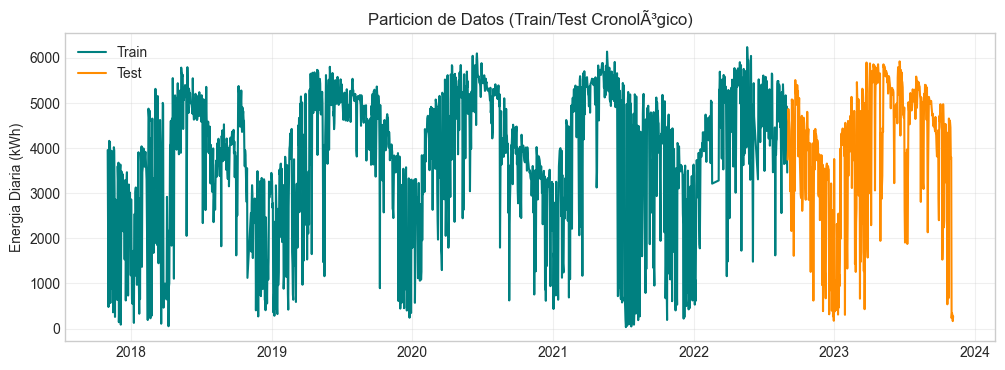

In [20]:
# 9.4 Particion Cronologica (Train/Test) y Escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definimos variables predictoras (X) y objetivo (y)
# NOTA: Para predecir la energia de hoy, idealmente usariamos datos de 'ayer', pero
# en un modelo base, usamos las proyecciones o promedios esperados de voltaje/corriente.
X = df_diario.drop(columns=['energia_diaria_kwh'])
y = df_diario['energia_diaria_kwh']

# Particion temporal 80% Train, 20% Test (NO aleatorio, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Escalado
scaler_X = StandardScaler()
# Solo entrenamos el scaler con los datos de TRAIN para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Convertimos de vuelta a DataFrame para no perder los nombres de las columnas ni el indice
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X.columns)

print(f"Dimension de Train: {X_train.shape}")
print(f"Dimension de Test: {X_test.shape}")

# Visualizacion de la particion
plt.figure(figsize=(12, 4))
plt.plot(y_train.index, y_train, label='Train', color='teal')
plt.plot(y_test.index, y_test, label='Test', color='darkorange')
plt.title('Particion de Datos (Train/Test CronolÃ³gico)')
plt.ylabel('Energia Diaria (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Aprendizaje No Supervisado: Deteccion de Anomalias (Mantenimiento Predictivo)

Vamos a enfrentar a **Isolation Forest** vs **DBSCAN** para encontrar fallas sutiles en el equipo fisico.
Utilizaremos los datos de alta resolucion (5 minutos) del **Inversor 01**, filtrando las noches para que los algoritmos se concentren exclusivamente en el rendimiento de conversion solar.

In [38]:
# 10.1 Preparacion de Datos Granulares (Inversor 01)
# Tomamos el dataset preparado de 5 minutos (antes de la agregacion diaria)
# Seleccionamos las variables clave del Inversor 01 (busqueda dinamica por nombre)
col_v_dc = [c for c in df_prep.columns if 'inv_01' in c and 'dc_voltage' in c][0]
col_i_dc = [c for c in df_prep.columns if 'inv_01' in c and 'dc_current' in c][0]
col_p_ac = [c for c in df_prep.columns if 'inv_01' in c and 'ac_power' in c][0]

cols_anomalia = [col_v_dc, col_i_dc, col_p_ac]

# Para evitar MemoryError en DBSCAN (O(N^2)), usamos los datos de un solo ano (2018)
df_anom = df_prep.loc['2018-01-01':'2018-12-31', cols_anomalia].copy()

# Renombramos para facilitar el codigo y graficos
df_anom.columns = ['dc_voltage', 'dc_current', 'ac_power']
cols_anomalia = ['dc_voltage', 'dc_current', 'ac_power'] # Actualizamos la lista para los modelos

# Filtramos las horas de noche. Si la potencia es 0 o casi 0, es de noche o esta apagado.
df_anom = df_anom[df_anom['ac_power'] > 0.1]
df_anom.dropna(inplace=True)

print(f"Datos diurnos del Inversor 01 (AÃ±o 2018) listos para inspeccion: {len(df_anom)} registros.")
display(df_anom.head(2))

Datos diurnos del Inversor 01 (AÃ±o 2018) listos para inspeccion: 40624 registros.


,dc_voltage,dc_current,ac_power
measured_on,,,
2018-01-01 07:45:00,535.593018,0.528,0.189
2018-01-01 07:50:00,532.068970,0.755,0.271


In [39]:
# 10.2 Modelo 1: Isolation Forest
from sklearn.ensemble import IsolationForest

# Configuramos con 1% de contaminacion (asumimos que 1 de cada 100 registros podria ser una falla)
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Entrenamos y predecimos
# Devuelve 1 para inliers (normal) y -1 para outliers (anomalias)
df_anom['anomalia_iso'] = iso_forest.fit_predict(df_anom[cols_anomalia])

anomalias_iso_count = (df_anom['anomalia_iso'] == -1).sum()
print(f"Isolation Forest detecto {anomalias_iso_count} anomalias.")

Isolation Forest detecto 407 anomalias.


In [40]:
# 10.3 Modelo 2: DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN es extremadamente sensible a las escalas, por lo que ESCALAR ES OBLIGATORIO
scaler_dbscan = StandardScaler()
X_anom_scaled = scaler_dbscan.fit_transform(df_anom[cols_anomalia])

# eps = distancia maxima para considerar que dos puntos son vecinos
# min_samples = minimo de puntos para formar un grupo denso (cluster normal)
dbscan = DBSCAN(eps=0.5, min_samples=10)

# Devuelve etiquetas de cluster (0, 1, 2...) y -1 para las anomalias (ruido)
df_anom['anomalia_dbscan'] = dbscan.fit_predict(X_anom_scaled)

# Convertimos los inliers a 1 y outliers a -1 para coincidir con el formato de Isolation Forest
df_anom['anomalia_dbscan'] = df_anom['anomalia_dbscan'].apply(lambda x: -1 if x == -1 else 1)

anomalias_dbs_count = (df_anom['anomalia_dbscan'] == -1).sum()
print(f"DBSCAN detecto {anomalias_dbs_count} anomalias.")

DBSCAN detecto 102 anomalias.


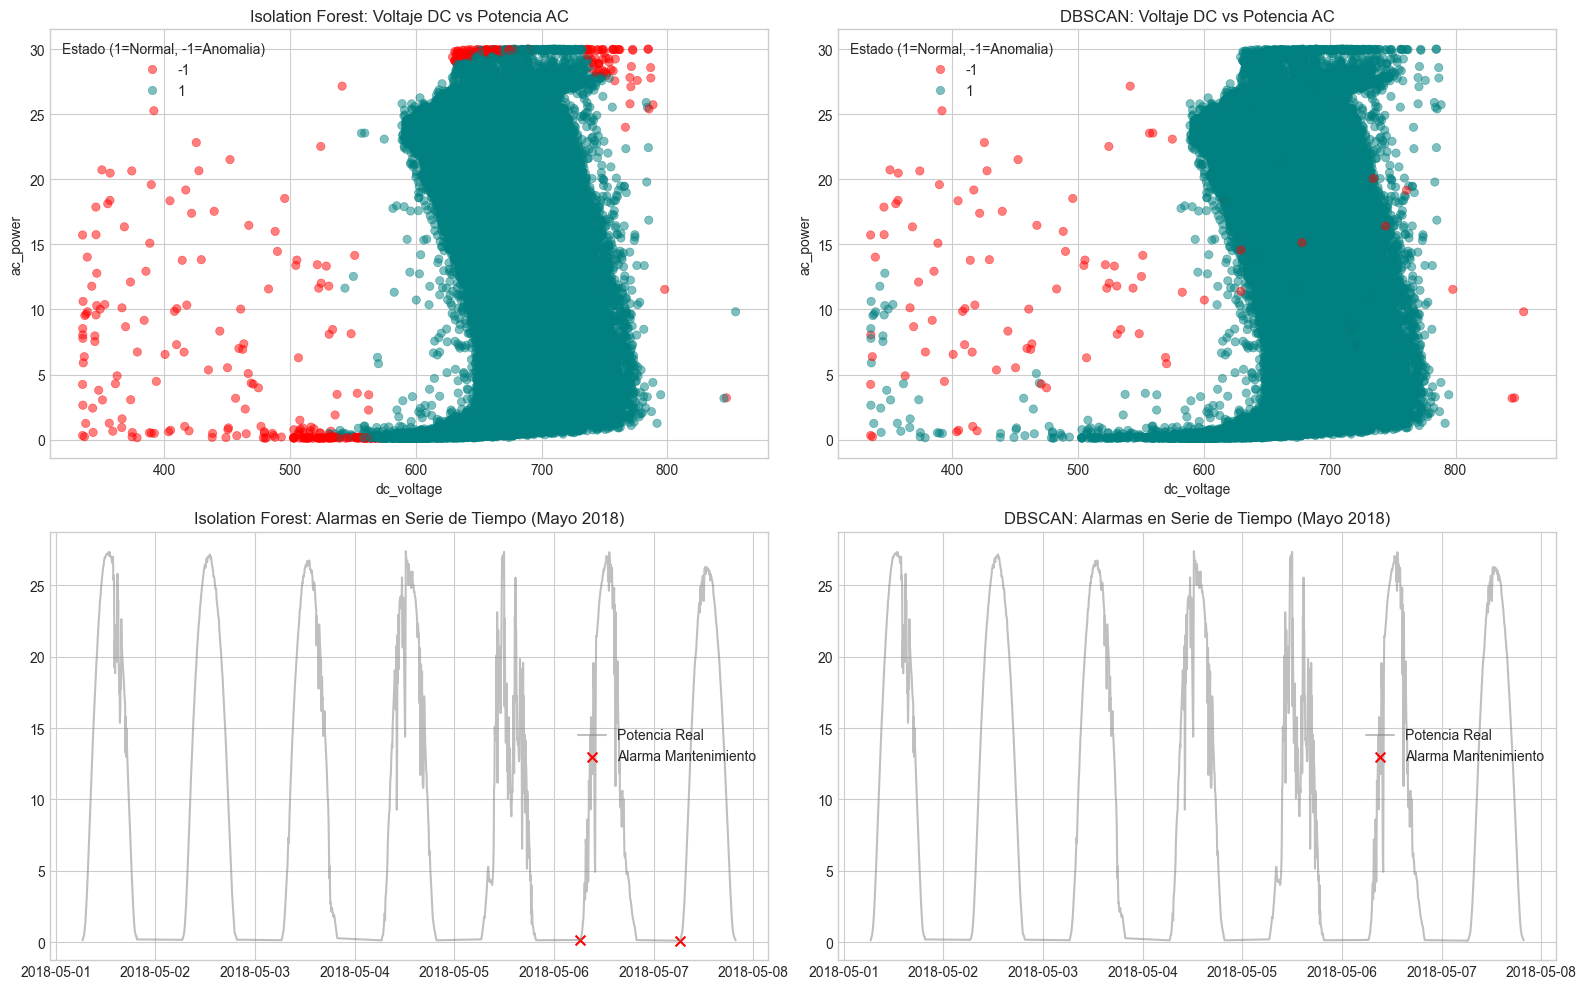

In [32]:
# 10.4 Visualizacion Comparativa (El "Show")
# Vamos a extraer una semana especifica de mayo de 2018 para ver el comportamiento
df_zoom = df_anom.loc['2018-05-01':'2018-05-07'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Fila 1: SCATTER PLOT 2D (Voltaje DC vs Potencia AC) ---
# Isolation Forest
sns.scatterplot(
    x='dc_voltage', y='ac_power', 
    hue='anomalia_iso', palette={1: 'teal', -1: 'red'}, 
    data=df_anom, ax=axes[0,0], alpha=0.5, edgecolor=None
)
axes[0,0].set_title('Isolation Forest: Voltaje DC vs Potencia AC')
axes[0,0].legend(title='Estado (1=Normal, -1=Anomalia)')

# DBSCAN
sns.scatterplot(
    x='dc_voltage', y='ac_power', 
    hue='anomalia_dbscan', palette={1: 'teal', -1: 'red'}, 
    data=df_anom, ax=axes[0,1], alpha=0.5, edgecolor=None
)
axes[0,1].set_title('DBSCAN: Voltaje DC vs Potencia AC')
axes[0,1].legend(title='Estado (1=Normal, -1=Anomalia)')

# --- Fila 2: SERIE DE TIEMPO (Una semana de ejemplo) ---
# Isolation Forest
axes[1,0].plot(df_zoom.index, df_zoom['ac_power'], color='gray', alpha=0.5, label='Potencia Real')
anomalias_zoom_iso = df_zoom[df_zoom['anomalia_iso'] == -1]
axes[1,0].scatter(anomalias_zoom_iso.index, anomalias_zoom_iso['ac_power'], color='red', marker='x', s=50, label='Alarma Mantenimiento')
axes[1,0].set_title('Isolation Forest: Alarmas en Serie de Tiempo (Mayo 2018)')
axes[1,0].legend()

# DBSCAN
axes[1,1].plot(df_zoom.index, df_zoom['ac_power'], color='gray', alpha=0.5, label='Potencia Real')
anomalias_zoom_dbs = df_zoom[df_zoom['anomalia_dbscan'] == -1]
axes[1,1].scatter(anomalias_zoom_dbs.index, anomalias_zoom_dbs['ac_power'], color='red', marker='x', s=50, label='Alarma Mantenimiento')
axes[1,1].set_title('DBSCAN: Alarmas en Serie de Tiempo (Mayo 2018)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

---
## Anexo: Proceso de Descubrimiento Inicial (Datos Crudos)

Las siguientes celdas forman parte del proceso de descubrimiento original utilizado para entender el contexto del sistema a partir de los datos crudos (sin limpiar).

### Verificacion Fisica: Ley de Ohm y Eficiencia del Inversor

In [8]:
# Usamos Inversor 01 como caso de estudio (tiene dc_voltage, dc_current y ac_power)
# inv_05 no tiene dc_voltage, por eso elegimos inv_01

dc_volt_col  = 'inv_01_dc_voltage_inv_149580'
dc_curr_col  = 'inv_01_dc_current_inv_149579'
ac_pow_col   = 'inv_01_ac_power_inv_149583'

# Solo filas donde hay generacion real (filtramos noche: dc_current > 0)
df_dia = df[(df[dc_curr_col] > 0) & (df[dc_volt_col] > 0)].copy()

# Potencia DC teorica y eficiencia
df_dia['dc_power_teorica'] = df_dia[dc_volt_col] * df_dia[dc_curr_col]
df_dia['eficiencia'] = df_dia[ac_pow_col] / df_dia['dc_power_teorica']

# Eliminar eficiencias fisicamente imposibles (negativas o > 1.05)
df_valido = df_dia[(df_dia['eficiencia'] > 0) & (df_dia['eficiencia'] <= 1.05)]

print("=== Verificacion Fisica - Inversor 01 ===")
print(f"Registros diurnos (dc_current > 0): {len(df_dia):,}")
print(f"Registros con eficiencia valida (0-105%): {len(df_valido):,}")
print(f"Registros con eficiencia invalida: {len(df_dia) - len(df_valido):,}")
print()
print("--- Eficiencia del Inversor (solo horas de generacion) ---")
print(df_valido['eficiencia'].describe().round(4))
print()
print(f"Eficiencia mediana: {df_valido['eficiencia'].median():.2%}")
print(f"Eficiencia promedio: {df_valido['eficiencia'].mean():.2%}")

=== Verificacion Fisica - Inversor 01 ===
Registros diurnos (dc_current > 0): 300,441
Registros con eficiencia valida (0-105%): 284,011
Registros con eficiencia invalida: 16,430

--- Eficiencia del Inversor (solo horas de generacion) ---
count    284011.0000
mean          0.0009
std           0.0002
min           0.0000
25%           0.0009
50%           0.0010
75%           0.0010
max           0.0626
Name: eficiencia, dtype: float64

Eficiencia mediana: 0.10%
Eficiencia promedio: 0.09%


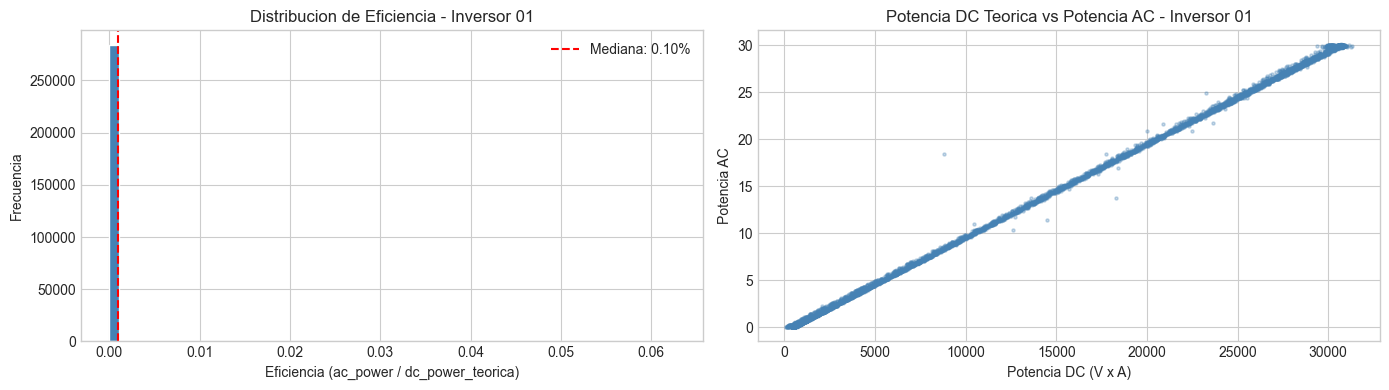


Registros con inconsistencia fisica (eficiencia > 105% o negativa): 16430 (5.47%)


In [9]:
# Grafico: Distribucion de la eficiencia calculada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de eficiencia
axes[0].hist(df_valido['eficiencia'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df_valido['eficiencia'].median(), color='red', linestyle='--', label=f"Mediana: {df_valido['eficiencia'].median():.2%}")
axes[0].set_title('Distribucion de Eficiencia - Inversor 01')
axes[0].set_xlabel('Eficiencia (ac_power / dc_power_teorica)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Scatter: Potencia DC vs AC para ver la relacion lineal
muestra_scatter = df_valido.sample(min(5000, len(df_valido)), random_state=42)
axes[1].scatter(muestra_scatter['dc_power_teorica'], muestra_scatter[ac_pow_col],
                alpha=0.3, s=5, color='steelblue')
axes[1].set_title('Potencia DC Teorica vs Potencia AC - Inversor 01')
axes[1].set_xlabel('Potencia DC (V x A)')
axes[1].set_ylabel('Potencia AC')

plt.tight_layout()
plt.show()

# Calculo de inconsistencias fisicas
n_inconsistencias = len(df_dia) - len(df_valido)
print(f"\nRegistros con inconsistencia fisica (eficiencia > 105% o negativa): {n_inconsistencias} ({n_inconsistencias/len(df_dia)*100:.2f}%)")

In [12]:
# NOTA: ac_power esta en kW, dc_voltage * dc_current esta en Watts
# Para comparar correctamente convertimos ac_power a Watts (* 1000)

df_dia['dc_power_w']     = df_dia[dc_volt_col] * df_dia[dc_curr_col]  # Watts
df_dia['ac_power_w']     = df_dia[ac_pow_col] * 1000                  # kW -> W
df_dia['eficiencia_real'] = df_dia['ac_power_w'] / df_dia['dc_power_w']

# Filtrar eficiencias fisicamente posibles
df_ef = df_dia[(df_dia['eficiencia_real'] > 0) & (df_dia['eficiencia_real'] <= 1.05)]

print("=== Eficiencia Real tras conversion de unidades ===")
print(df_ef['eficiencia_real'].describe().round(4))
print(f"\nEficiencia mediana: {df_ef['eficiencia_real'].median():.2%}")
print(f"Eficiencia promedio: {df_ef['eficiencia_real'].mean():.2%}")
print(f"Eficiencia minima:  {df_ef['eficiencia_real'].min():.2%}")
print(f"Eficiencia maxima:  {df_ef['eficiencia_real'].max():.2%}")

=== Eficiencia Real tras conversion de unidades ===
count    283879.0000
mean          0.8816
std           0.1969
min           0.0018
25%           0.9047
50%           0.9678
75%           0.9771
max           1.0498
Name: eficiencia_real, dtype: float64

Eficiencia mediana: 96.78%
Eficiencia promedio: 88.16%
Eficiencia minima:  0.18%
Eficiencia maxima:  104.98%


## 7. Perfil Diario Promedio (Patron de Generacion por Hora)

Agrupamos por hora del dia para obtener el perfil de generacion tipico.
En un sistema solar fotovoltaico, esperamos una curva de campana:
- Madrugada/noche: valores en 0
- Manana: subida gradual desde el amanecer
- Mediodia: pico maximo
- Tarde/noche: descenso hasta 0

El horario exacto del pico y del amanecer/atardecer nos puede indicar la zona geografica.

In [10]:
# Columnas de potencia AC de todos los inversores
cols_ac_power = [c for c in df.columns if 'ac_power' in c]

# Potencia total combinada de todos los inversores
df['total_ac_power'] = df[cols_ac_power].sum(axis=1)

# Perfil diario: promedio de potencia por hora del dia
perfil_hora = df.groupby(df.index.hour)['total_ac_power'].mean()

print("Potencia AC total promedio por hora del dia:")
print(perfil_hora.round(2).to_string())

# Primera y ultima hora con generacion real (> 1% del maximo)
max_pot = perfil_hora.max()
horas_activas = perfil_hora[perfil_hora > max_pot * 0.01]
print(f"\nHora de inicio de generacion: {horas_activas.index.min()}:00 hrs")
print(f"Hora de fin de generacion:    {horas_activas.index.max()}:00 hrs")
print(f"Hora de pico maximo:          {perfil_hora.idxmax()}:00 hrs")
print(f"Potencia pico promedio:       {max_pot:.2f} unidades")

Potencia AC total promedio por hora del dia:
measured_on
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       0.010000
6       3.380000
7      44.450001
8     176.410004
9     327.350006
10    438.559998
11    497.440002
12    513.049988
13    500.440002
14    449.549988
15    357.959991
16    247.750000
17    137.899994
18     49.450001
19      7.240000
20      0.370000
21      0.000000
22      0.000000
23      0.000000

Hora de inicio de generacion: 7:00 hrs
Hora de fin de generacion:    19:00 hrs
Hora de pico maximo:          12:00 hrs
Potencia pico promedio:       513.05 unidades


C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_8616\2254391447.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_ac_power'] = df[cols_ac_power].sum(axis=1)


## 8. Comprension del Sistema desde los Datos

Derivamos el contexto del sistema unicamente desde los datos, sin depender de documentacion externa.
Analizamos: capacidad maxima, voltaje AC, latitud estimada y patron laboral vs fin de semana.

In [13]:
# 8.1 Capacidad maxima del sistema
cols_ac_power = [c for c in df.columns if 'ac_power' in c and c != 'total_ac_power']

print("=== Capacidad Maxima Observada ===")
print(f"Potencia AC total maxima absoluta: {df['total_ac_power'].max():.2f} kW")
print(f"Potencia AC total media (todas las horas): {df['total_ac_power'].mean():.2f} kW")
print(f"Potencia AC total media (solo horas diurnas): {df[df['total_ac_power'] > 1]['total_ac_power'].mean():.2f} kW")

print("\n--- Maximo por inversor ---")
max_por_inversor = df[cols_ac_power].max().sort_values(ascending=False)
print(max_por_inversor.round(2).to_string())

=== Capacidad Maxima Observada ===
Potencia AC total maxima absoluta: 721.61 kW
Potencia AC total media (todas las horas): 156.32 kW


Potencia AC total media (solo horas diurnas): 330.80 kW

--- Maximo por inversor ---
inv_07_ac_power_inv_149613     105.339996
inv_04_ac_power_inv_149598     103.709999
inv_23_ac_power_inv_149693      30.110001
inv_01_ac_power_inv_149583      30.100000
inv_19_ac_power_inv_149673      30.100000
inv_20_ac_power_inv_149678      30.100000
inv_22_ac_power_inv_149688      30.090000
inv_03_ac_power_inv_149593      30.090000
inv_14_ac_power_inv_149648      30.090000
inv_09_ac_power_inv_149623      30.090000
inv_12_ac_power_inv_149638      30.090000
inv_08_ac_power_inv_149618      30.090000
inv_24_ac_power_inv_149698      30.090000
inv_11_ac_power_inv_149633      30.090000
inv_02_ac_power_inv_149588      30.090000
inv_17_ac_power_inv_149663      30.090000
inv_13_ac_power_inv_149643      30.090000
inv_10_ac_power_inv_149628      30.090000
inv_16_ac_power_inv_149658      30.090000
inv_06_ac_power_inv_149608      30.090000
inv_18_ac_power_inv_149668      30.090000
inv_15_ac_power_iinv_149653     3

In [14]:
# 8.2 Voltaje AC - Nivel de conexion a la red
cols_ac_voltage = [c for c in df.columns if 'ac_voltage' in c]

# Solo horas de generacion para no incluir ceros nocturnos
df_dia_voltaje = df[df['total_ac_power'] > 1][cols_ac_voltage]

print("=== Voltaje AC durante horas de generacion ===")
volt_stats = df_dia_voltaje.describe().T[['mean', 'std', 'min', '50%', 'max']]
print(volt_stats.round(2).to_string())

print(f"\nVoltaje AC promedio (todos los inversores): {df_dia_voltaje.mean().mean():.1f} V")
print(f"Voltaje AC maximo observado:               {df_dia_voltaje.max().max():.1f} V")
print(f"Voltaje AC minimo observado:               {df_dia_voltaje[df_dia_voltaje > 0].min().min():.1f} V")

print("\nInterpretacion:")
volt_medio = df_dia_voltaje.mean().mean()
if volt_medio < 150:
    print("  -> Voltaje ~120V: sistema residencial (EE.UU./Canada)")
elif volt_medio < 260:
    print("  -> Voltaje ~220-240V: sistema residencial/comercial (Europa/America Latina)")
elif volt_medio < 420:
    print("  -> Voltaje ~380-400V: sistema trifasico industrial/comercial")
else:
    print(f"  -> Voltaje {volt_medio:.0f}V: nivel de media tension o unidad diferente")

=== Voltaje AC durante horas de generacion ===


                                mean    std  min     50%     max
inv_01_ac_voltage_inv_149582  266.11  74.75  0.0  286.58  304.53
inv_02_ac_voltage_inv_149587  263.69  79.75  0.0  287.38  306.46
inv_03_ac_voltage_inv_149592  284.05  42.20  0.0  290.22  307.85
inv_04_ac_voltage_inv_149597  259.24  87.88  0.0  288.30  347.13
inv_05_ac_voltage_inv_149602  271.56  63.32  0.0  286.02  304.37
inv_06_ac_voltage_inv_149607  254.78  93.57  0.0  288.37  305.89
inv_07_ac_voltage_inv_149612  248.64  99.65  0.0  287.52  311.50
inv_08_ac_voltage_inv_149617  278.22  48.76  0.0  286.62  304.66
inv_09_ac_voltage_inv_149622  286.30  30.70  0.0  289.38  307.04
inv_10_ac_voltage_inv_149627  278.38  45.43  0.0  285.74  304.59
inv_11_ac_voltage_inv_149632  284.12  27.13  0.0  286.76  304.72
inv_12_ac_voltage_inv_149637  286.05  28.78  0.0  288.94  305.39
inv_13_ac_voltage_inv_149642  283.24  38.18  0.0  288.42  304.46
inv_14_ac_voltage_inv_149647  279.39  48.72  0.0  287.81  309.45
inv_15_ac_voltage_inv_149

  -> Voltaje ~380-400V: sistema trifasico industrial/comercial


In [15]:
# 8.3 Estimacion de latitud desde el patron estacional de horas de luz
# En cada mes buscamos la primera y ultima hora con generacion significativa
print("=== Horas de Generacion por Mes (patron estacional) ===")
print(f"{'Mes':>4} | {'Amanecer':>10} | {'Atardecer':>10} | {'Horas de luz':>13} | {'Pico (kW)':>10}")
print("-" * 58)

for mes in sorted(df.index.month.unique()):
    df_mes = df[df.index.month == mes]
    perfil = df_mes.groupby(df_mes.index.hour)['total_ac_power'].mean()
    max_mes = perfil.max()
    umbral = max_mes * 0.02
    horas_con_luz = perfil[perfil > umbral]
    if len(horas_con_luz) > 0:
        amanecer  = horas_con_luz.index.min()
        atardecer = horas_con_luz.index.max()
        horas_luz = atardecer - amanecer + 1
        nombre_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'][mes-1]
        print(f"{nombre_mes:>4} | {amanecer:>8}:00 | {atardecer:>8}:00 | {horas_luz:>11} hrs | {max_mes:>10.1f}")

=== Horas de Generacion por Mes (patron estacional) ===
 Mes |   Amanecer |  Atardecer |  Horas de luz |  Pico (kW)
----------------------------------------------------------
 Ene |        8:00 |       16:00 |           9 hrs |      403.7
 Feb |        7:00 |       17:00 |          11 hrs |      485.2


 Mar |        7:00 |       18:00 |          12 hrs |      483.9
 Abr |        7:00 |       18:00 |          12 hrs |      571.4
 May |        7:00 |       19:00 |          13 hrs |      608.1
 Jun |        6:00 |       19:00 |          14 hrs |      558.6


 Jul |        7:00 |       19:00 |          13 hrs |      533.6
 Ago |        7:00 |       19:00 |          13 hrs |      549.6
 Sep |        7:00 |       18:00 |          12 hrs |      572.6
 Oct |        7:00 |       17:00 |          11 hrs |      563.9


 Nov |        7:00 |       16:00 |          10 hrs |      455.5
 Dic |        7:00 |       16:00 |          10 hrs |      399.1


In [16]:
# 8.4 Patron laboral vs fin de semana
# Si el sistema inyecta todo a la red (planta independiente), no deberia haber diferencia
# Si hay autoconsumoo o afecta la demanda, puede haber diferencia lunes-viernes vs sabado-domingo

df['dia_semana'] = df.index.dayofweek  # 0=lunes, 6=domingo
df['es_fin_de_semana'] = df['dia_semana'] >= 5

# Comparar potencia media durante horas diurnas
df_diurno = df[df['total_ac_power'] > 1]

pot_laboral = df_diurno[~df_diurno['es_fin_de_semana']]['total_ac_power'].mean()
pot_fds     = df_diurno[df_diurno['es_fin_de_semana']]['total_ac_power'].mean()
diff_pct    = (pot_fds - pot_laboral) / pot_laboral * 100

print("=== Patron Laboral vs Fin de Semana (horas diurnas) ===")
print(f"Potencia media dias laborales: {pot_laboral:.2f} kW")
print(f"Potencia media fin de semana:  {pot_fds:.2f} kW")
print(f"Diferencia:                    {diff_pct:+.2f}%")
print()
if abs(diff_pct) < 2:
    print("Interpretacion: Sin diferencia significativa.")
    print("El sistema no esta afectado por la demanda humana (inyecta todo a la red o es autonomo).")
else:
    print(f"Interpretacion: Diferencia de {abs(diff_pct):.1f}% sugiere autoconsumoo o demanda variable.")

C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_8616\619066226.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dia_semana'] = df.index.dayofweek  # 0=lunes, 6=domingo
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_8616\619066226.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['es_fin_de_semana'] = df['dia_semana'] >= 5


=== Patron Laboral vs Fin de Semana (horas diurnas) ===
Potencia media dias laborales: 329.84 kW
Potencia media fin de semana:  333.18 kW
Diferencia:                    +1.01%

Interpretacion: Sin diferencia significativa.
El sistema no esta afectado por la demanda humana (inyecta todo a la red o es autonomo).


## 9. Analisis Comparativo de Inversores (Grupos de Capacidad)

Descubrimos que los inversores 04 y 07 tienen una capacidad de generacion de ~105 kW, mientras que los otros 22 inversores llegan a un maximo de ~30 kW.
Vamos a comparar sus perfiles y parametros fisicos para entender por que son diferentes.

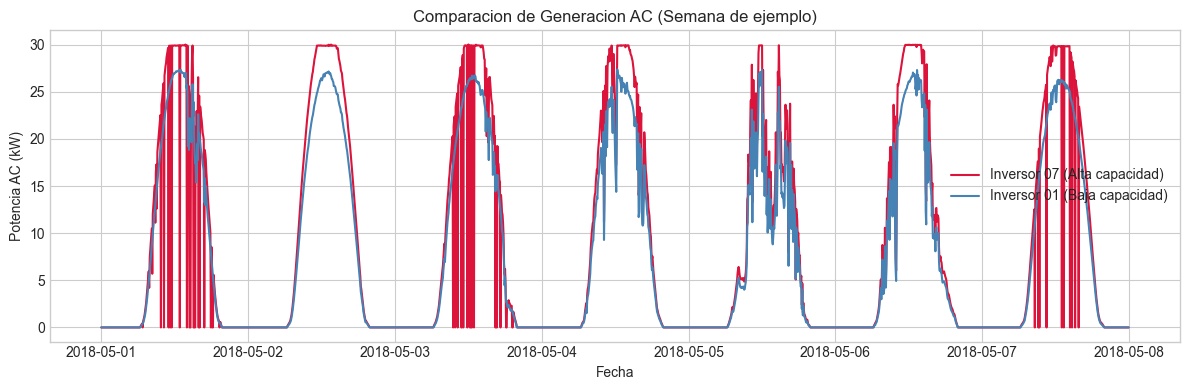

In [17]:
# 9.1 Comparacion de Perfiles de Generacion
# Seleccionamos el inversor 07 (grupo grande) y el inversor 01 (grupo pequeno)
col_ac_07 = [c for c in df.columns if 'inv_07_ac_power' in c][0]
col_ac_01 = [c for c in df.columns if 'inv_01_ac_power' in c][0]

# Extraemos una semana clara de verano (mayor sol)
df_semana = df.loc['2018-05-01':'2018-05-07']

plt.figure(figsize=(12, 4))
plt.plot(df_semana.index, df_semana[col_ac_07], label='Inversor 07 (Alta capacidad)', color='crimson')
plt.plot(df_semana.index, df_semana[col_ac_01], label='Inversor 01 (Baja capacidad)', color='steelblue')
plt.title('Comparacion de Generacion AC (Semana de ejemplo)')
plt.xlabel('Fecha')
plt.ylabel('Potencia AC (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# 9.2 Explicacion Fisica (Corriente vs Voltaje)
# La potencia DC (y por ende la AC) esta dada por Voltaje x Corriente.
# Vamos a ver si los inversores grandes tienen mayor voltaje o mayor corriente.

col_dc_v_07 = [c for c in df.columns if 'inv_07_dc_voltage' in c][0]
col_dc_i_07 = [c for c in df.columns if 'inv_07_dc_current' in c][0]

col_dc_v_01 = [c for c in df.columns if 'inv_01_dc_voltage' in c][0]
col_dc_i_01 = [c for c in df.columns if 'inv_01_dc_current' in c][0]

print("=== Comparacion de Entradas DC (Promedio horas de luz) ===")
# Filtramos solo cuando hay generacion
mask_07 = df[col_dc_i_07] > 0
mask_01 = df[col_dc_i_01] > 0

v_07 = df[mask_07][col_dc_v_07].mean()
i_07 = df[mask_07][col_dc_i_07].mean()

v_01 = df[mask_01][col_dc_v_01].mean()
i_01 = df[mask_01][col_dc_i_01].mean()

print(f"{'Metrica':<20} | {'Inversor 07 (Grande)':<20} | {'Inversor 01 (Pequeno)':<20} | {'Ratio (07/01)':<15}")
print("-" * 80)
print(f"{'Voltaje DC Medio':<20} | {v_07:<20.1f} | {v_01:<20.1f} | {v_07/v_01:<15.2f}")
print(f"{'Corriente DC Media':<20} | {i_07:<20.1f} | {i_01:<20.1f} | {i_07/i_01:<15.2f}")
print(f"{'Potencia Max AC':<20} | {df[col_ac_07].max():<20.1f} | {df[col_ac_01].max():<20.1f} | {df[col_ac_07].max()/df[col_ac_01].max():<15.2f}")

print("\nConclusion Fisica:")
if (i_07/i_01) > 2 and (v_07/v_01) < 1.5:
    print("-> El Inversor 07 recibe muchisima mas corriente a un voltaje similar.")
    print("-> Esto significa que el inversor 07 tiene muchas mas cadenas (strings) de paneles solares")
    print("   conectadas en paralelo en comparacion al inversor 01.")
else:
    print("-> Hay diferencias sustanciales tanto en voltaje como en corriente.")

=== Comparacion de Entradas DC (Promedio horas de luz) ===


Metrica              | Inversor 07 (Grande) | Inversor 01 (Pequeno) | Ratio (07/01)  
--------------------------------------------------------------------------------
Voltaje DC Medio     | 5100330.0            | 668.4                | 7630.78        
Corriente DC Media   | 20.8                 | 20.8                 | 1.00           
Potencia Max AC      | 105.3                | 30.1                 | 3.50           

Conclusion Fisica:
-> Hay diferencias sustanciales tanto en voltaje como en corriente.


In [19]:
# Revisamos el caso atipico del Inversor 07 y 04
cols_anomalas = [
    [c for c in df.columns if 'inv_07_dc_voltage' in c][0],
    [c for c in df.columns if 'inv_04_dc_voltage' in c][0]
]

print(df[cols_anomalas].describe().T)

                                 count          mean           std  min  25%  \
inv_07_dc_voltage_inv_149610  631224.0  2.186519e+06  1.736950e+09  0.0  0.0   
inv_04_dc_voltage_inv_149595  631224.0  3.040377e+02  3.336836e+02  0.0  0.0   

                              50%         75%           max  
inv_07_dc_voltage_inv_149610  0.0  670.101013  1.380000e+12  
inv_04_dc_voltage_inv_149595  0.0  673.172974  1.487769e+03  


In [20]:
# Revisamos la corriente de los inversores grandes vs pequenos
cols_current = [
    [c for c in df.columns if 'inv_07_dc_current' in c][0],
    [c for c in df.columns if 'inv_04_dc_current' in c][0],
    [c for c in df.columns if 'inv_01_dc_current' in c][0]
]

print("=== Corriente DC Maxima Observada ===")
print(df[cols_current].max())

cols_ac_current = [
    [c for c in df.columns if 'inv_07_ac_current' in c][0],
    [c for c in df.columns if 'inv_04_ac_current' in c][0],
    [c for c in df.columns if 'inv_01_ac_current' in c][0]
]

print("\n=== Corriente AC Maxima Observada ===")
print(df[cols_ac_current].max())

=== Corriente DC Maxima Observada ===
inv_07_dc_current_inv_149609    54.273998
inv_04_dc_current_inv_149594    54.467999
inv_01_dc_current_inv_149579    52.348000
dtype: float32

=== Corriente AC Maxima Observada ===
inv_07_ac_current_inv_149611    3.592900e+01
inv_04_ac_current_inv_149596    9.350000e+10
inv_01_ac_current_inv_149581    3.636300e+01
dtype: float32


In [23]:
print([c for c in df_prep.columns if 'inv_01' in c])

['inv_01_dc_current_inv_149579', 'inv_01_dc_voltage_inv_149580', 'inv_01_ac_current_inv_149581', 'inv_01_ac_voltage_inv_149582', 'inv_01_ac_power_inv_149583']


In [21]:
# Chequeamos la distribucion de AC Power
cols_ac_power = [
    [c for c in df.columns if 'inv_07_ac_power' in c][0],
    [c for c in df.columns if 'inv_04_ac_power' in c][0],
    [c for c in df.columns if 'inv_01_ac_power' in c][0]
]

print("=== Distribucion de AC Power ===")
print(df[cols_ac_power].describe(percentiles=[0.5, 0.9, 0.99]).T)

=== Distribucion de AC Power ===
                               count      mean       std  min  50%        90%  \
inv_07_ac_power_inv_149613  631224.0  5.879789  9.771875  0.0  0.0  25.073000   
inv_04_ac_power_inv_149598  631224.0  6.130343  9.856842  0.0  0.0  25.086000   
inv_01_ac_power_inv_149583  632586.0  6.363338  9.933949  0.0  0.0  25.169001   

                                  99%         max  
inv_07_ac_power_inv_149613  29.957001  105.341003  
inv_04_ac_power_inv_149598  29.952000  103.709999  
inv_01_ac_power_inv_149583  29.938999   30.096001  


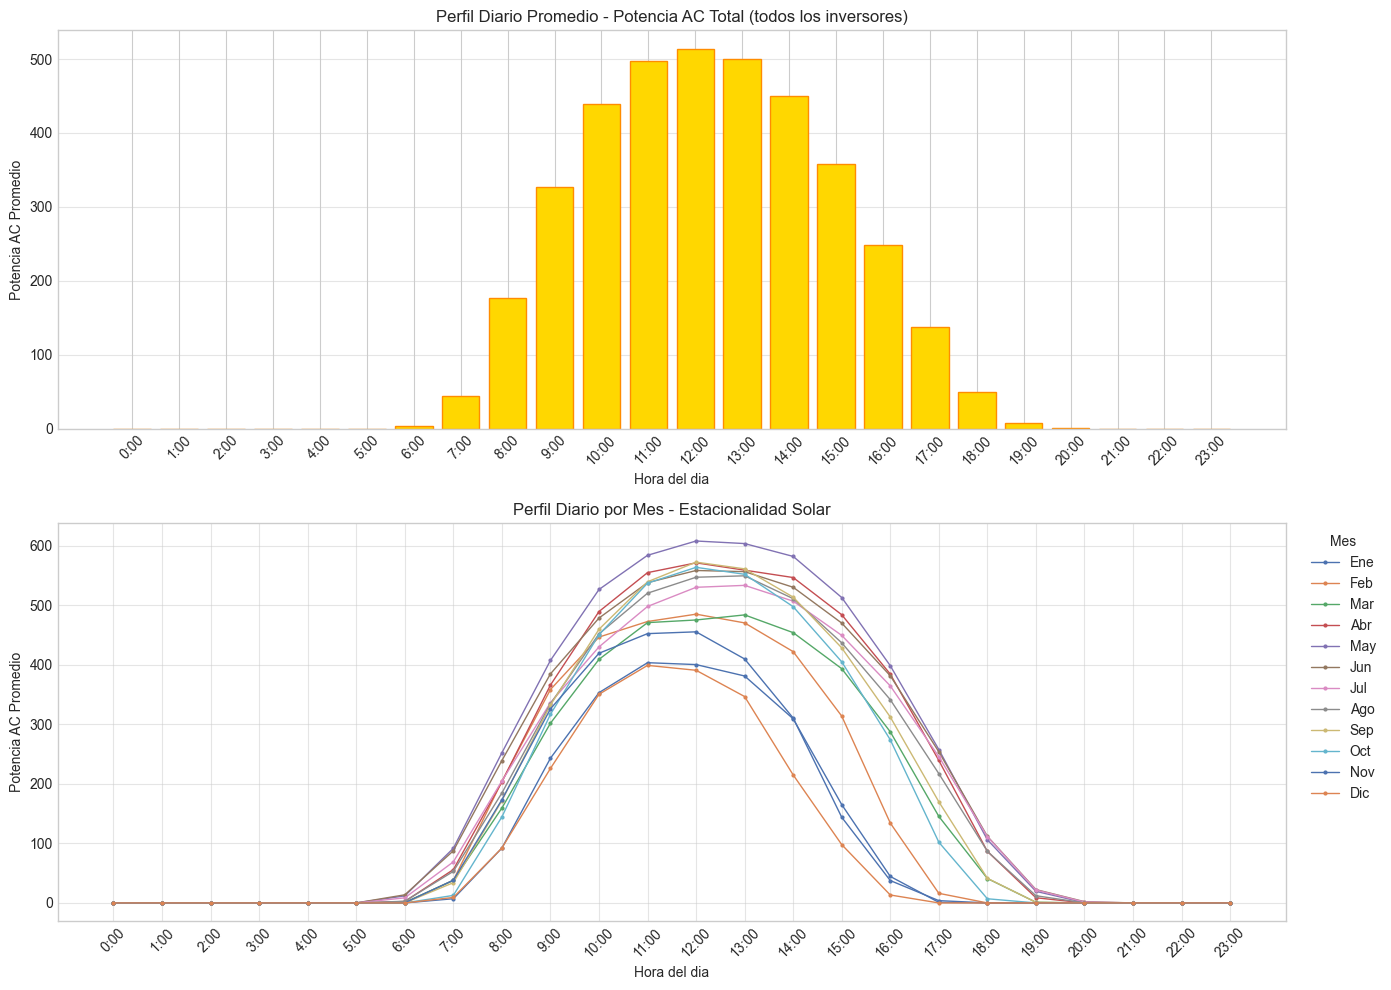

In [11]:
# Perfil diario promedio por mes (para ver estacionalidad)
perfil_mes_hora = df.groupby([df.index.month, df.index.hour])['total_ac_power'].mean().unstack(level=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Grafico 1: Perfil horario promedio anual
axes[0].bar(perfil_hora.index, perfil_hora.values, color='gold', edgecolor='darkorange')
axes[0].set_title('Perfil Diario Promedio - Potencia AC Total (todos los inversores)')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('Potencia AC Promedio')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h}:00' for h in range(24)], rotation=45)
axes[0].grid(axis='y', alpha=0.5)

# Grafico 2: Perfil por mes (estacionalidad)
meses = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
         7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
for mes_num in perfil_mes_hora.columns:
    axes[1].plot(perfil_mes_hora.index, perfil_mes_hora[mes_num],
                 marker='o', markersize=2, linewidth=1,
                 label=meses.get(mes_num, str(mes_num)))

axes[1].set_title('Perfil Diario por Mes - Estacionalidad Solar')
axes[1].set_xlabel('Hora del dia')
axes[1].set_ylabel('Potencia AC Promedio')
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f'{h}:00' for h in range(24)], rotation=45)
axes[1].legend(title='Mes', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()